In [1]:
import os
import random
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms as transforms
import cv2
!pip install split-folders
import splitfolders
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import torch.optim as optim
import copy
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
source_dir = '/content/drive/MyDrive/Data DL/Data Awal'
dest_dir = './dataset_balanced'
categories = ['car', 'bus', 'motorbike']
limit = 1500

if not os.path.exists(dest_dir):
    os.makedirs(dest_dir)

for category in categories:
    source_path = os.path.join(source_dir, category)
    dest_path = os.path.join(dest_dir, category)

    if not os.path.exists(dest_path):
        os.makedirs(dest_path)

    valid_extensions = ('.jpg', '.jpeg', '.png')
    all_files = [f for f in os.listdir(source_path) if f.lower().endswith(valid_extensions)]

    if len(all_files) >= limit:
        selected_files = random.sample(all_files, limit)
    else:
        print(f"'{category}' only have {len(all_files)} images.")
        selected_files = all_files

    print(f"Copying {len(selected_files)} iamges to folder {dest_dir}/{category}")
    for file_name in selected_files:
        src_file = os.path.join(source_path, file_name)
        dst_file = os.path.join(dest_path, file_name)
        shutil.copy(src_file, dst_file)

print("\nProses selesai")

Copying 1500 iamges to folder ./dataset_balanced/car
'bus' only have 1000 images.
Copying 1000 iamges to folder ./dataset_balanced/bus
Copying 1500 iamges to folder ./dataset_balanced/motorbike

Proses selesai


In [3]:
def clean_dataset(directory, blur_threshold=100.0):
    categories = ['car', 'bus', 'motorbike']
    for category in categories:
        path = os.path.join(directory, category)
        removed_count = 0

        for filename in os.listdir(path):
            file_path = os.path.join(path, filename)

            if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                os.remove(file_path)
                removed_count += 1
                continue

            img = cv2.imread(file_path)

            if img is None:
                print(f'Menghapus file korup: {filename}')
                os.remove(file_path)
                removed_count += 1
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            fm = cv2.Laplacian(gray, cv2.CV_64F).var()

            if fm < blur_threshold:
              os.remove(file_path)
              removed_count += 1

        print(f"Kategori {category.upper()}: Selesai dibersihkan. {removed_count} file tidak valid dihapus.")

dataset_path = '/content/dataset_balanced'
clean_dataset(dataset_path, blur_threshold=100.0)

Kategori CAR: Selesai dibersihkan. 11 file tidak valid dihapus.
Kategori BUS: Selesai dibersihkan. 1 file tidak valid dihapus.
Kategori MOTORBIKE: Selesai dibersihkan. 23 file tidak valid dihapus.


/tmp/ipykernel_1655/3286229143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Category', y='Count', data=df, palette='viridis')


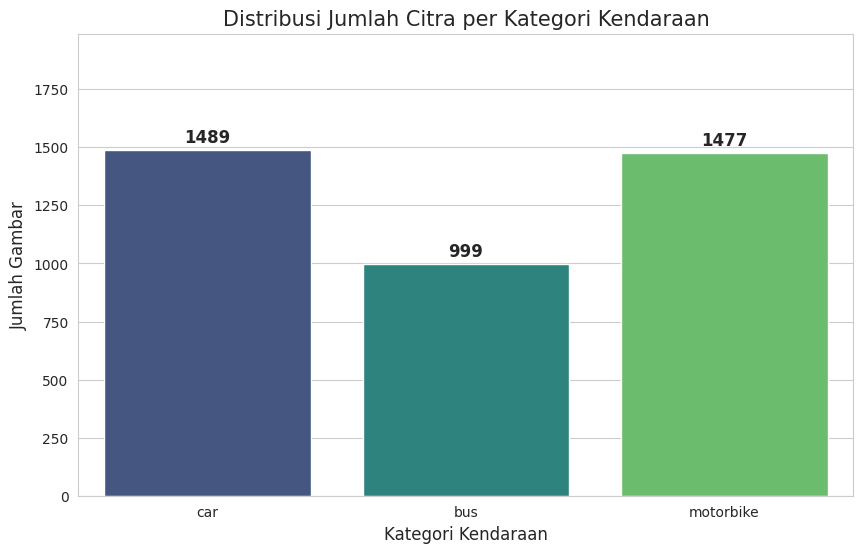

In [4]:
def plot_distribution(directory):
    data_counts = []
    categories = os.listdir(directory)

    for category in categories:
        path = os.path.join(directory, category)
        if os.path.isdir(path):
            count = len(os.listdir(path))
            data_counts.append({'Category': category, 'Count': count})

    df = pd.DataFrame(data_counts)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.barplot(x='Category', y='Count', data=df, palette='viridis')

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=12, fontweight='bold')

    plt.title('Distribusi Jumlah Citra per Kategori Kendaraan', fontsize=15)
    plt.xlabel('Kategori Kendaraan', fontsize=12)
    plt.ylabel('Jumlah Gambar', fontsize=12)
    plt.ylim(0, df['Count'].max() + 500)
    plt.show()

plot_distribution(dataset_path)

In [5]:
input_dir = '/content/dataset_balanced'
output_folder = '/content/dataset_split'

print("Splitting data")
splitfolders.ratio(
    input_dir,
    output = output_folder,
    seed=42,
    ratio=(0.8, 0.1, 0.1),
    group_prefix=None
)
print("Data sudah di split")

Splitting data


Copying files: 3965 files [00:01, 2080.61 files/s]

Data sudah di split


In [6]:
def augment_minority_class(class_dir, target_count):
    valid_extensions = ('.jpg', '.jpeg', '.png')
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
    current_count = len(images)

    if current_count >= target_count:
        print(f"{class_dir} sudah cukup target {current_count} gambar.")
        return

    needed_count = target_count - current_count
    print(f"{class_dir} perlu {needed_count} gambar. Memulai augmentasi")

    aug_transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.RandomHorizontalFlip(p=0.5)
    ])

    count = 0
    img_index = 0
    random.shuffle(images)

    while count < needed_count:
        img_name = images[img_index % len(images)]
        img_path = os.path.join(class_dir, img_name)

        try:
            img = Image.open(img_path).convert('RGB')
            aug_img = aug_transform(img)
            new_filename = f"aug_{count}_{img_name}"
            aug_img.save(os.path.join(class_dir, new_filename))

            count += 1
            if count % 100 == 0:
                print(f"Progres: {count}/{needed_count} gambar berhasil dibuat.")
        except Exception as e:
            print(f"Gagal memproses {img_name}: {e}")

        img_index += 1

    print(f"Total gambar akhir di folder: {len(os.listdir(class_dir))}")

bus_train_path = '/content/dataset_split/train/bus'
augment_minority_class(bus_train_path, target_count=1200)

/content/dataset_split/train/bus perlu 401 gambar. Memulai augmentasi
Progres: 100/401 gambar berhasil dibuat.
Progres: 200/401 gambar berhasil dibuat.
Progres: 300/401 gambar berhasil dibuat.
Progres: 400/401 gambar berhasil dibuat.
Total gambar akhir di folder: 1200


In [7]:
mean_z = [0.485, 0.456, 0.406]
std_z = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_z, std=std_z)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_z, std=std_z)
])

train_dataset = datasets.ImageFolder(root='/content/dataset_split/train', transform=train_transform)
val_dataset = datasets.ImageFolder(root='/content/dataset_split/val', transform=val_test_transform)
test_dataset = datasets.ImageFolder(root='/content/dataset_split/test', transform=val_test_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Jumlah batch latih: {len(train_loader)}")
print(f"{train_dataset.class_to_idx}")

Jumlah batch latih: 112
{'bus': 0, 'car': 1, 'motorbike': 2}


In [8]:
class VehicleClassifierCNN(nn.Module):
    def __init__(self):
        super(VehicleClassifierCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc1 = nn.Linear(128 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VehicleClassifierCNN().to(device)

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
       BatchNorm2d-5         [-1, 64, 112, 112]             128
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
       BatchNorm2d-8          [-1, 128, 56, 56]             256
         MaxPool2d-9          [-1, 128, 28, 28]               0
AdaptiveAvgPool2d-10            [-1, 128, 7, 7]               0
           Linear-11                  [-1, 128]         802,944
          Dropout-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 897,027
Trainable params:

In [9]:
EPOCHS = 30
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [10]:
patience = 10
patience_counter = 0
best_val_acc = 0.0
best_model_weights = copy.deepcopy(model.state_dict())

print("Training\n")

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(" Menyimpan model")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\n Early Stopping")
        break

print("\nTrain selesai")
print(f"Akurasi Val Tertinggi: {best_val_acc:.4f}")

model.load_state_dict(best_model_weights)
torch.save(model.state_dict(), "model_kendaraan_cnn_terbaik.pth")
print("File model berhasil disimpan sebagai 'model_kendaraan_cnn_terbaik.pth'")

Training



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/30] Train Loss: 1.0099, Train Acc: 0.5812 | Val Loss: 0.8218, Val Acc: 0.6853
 Menyimpan model
Epoch [2/30] Train Loss: 0.7542, Train Acc: 0.7388 | Val Loss: 0.6569, Val Acc: 0.8096
 Menyimpan model
Epoch [3/30] Train Loss: 0.7069, Train Acc: 0.7788 | Val Loss: 0.6147, Val Acc: 0.8223
 Menyimpan model
Epoch [4/30] Train Loss: 0.6474, Train Acc: 0.8191 | Val Loss: 0.5142, Val Acc: 0.8832
 Menyimpan model
Epoch [5/30] Train Loss: 0.6035, Train Acc: 0.8497 | Val Loss: 0.6198, Val Acc: 0.8198
Epoch [6/30] Train Loss: 0.5948, Train Acc: 0.8527 | Val Loss: 0.4991, Val Acc: 0.8807
Epoch [7/30] Train Loss: 0.5921, Train Acc: 0.8572 | Val Loss: 0.5442, Val Acc: 0.8655
Epoch [8/30] Train Loss: 0.5610, Train Acc: 0.8793 | Val Loss: 0.5383, Val Acc: 0.8782
Epoch [9/30] Train Loss: 0.5616, Train Acc: 0.8782 | Val Loss: 0.4905, Val Acc: 0.9061
 Menyimpan model
Epoch [10/30] Train Loss: 0.5521, Train Acc: 0.8807 | Val Loss: 0.4988, Val Acc: 0.9036
Epoch [11/30] Train Loss: 0.5476, Train Acc:

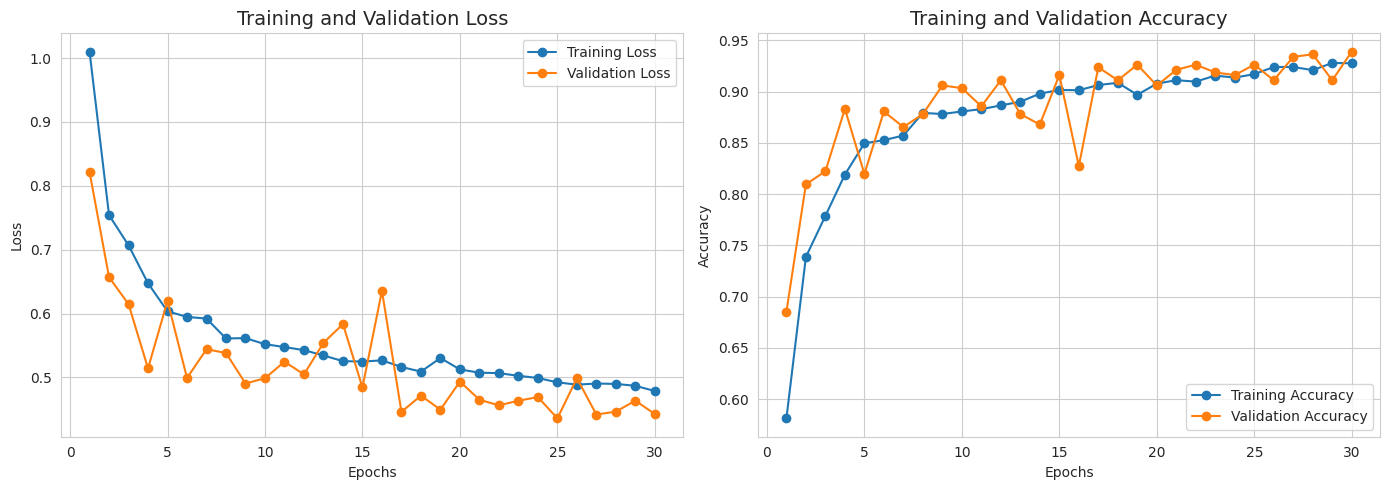

In [11]:
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

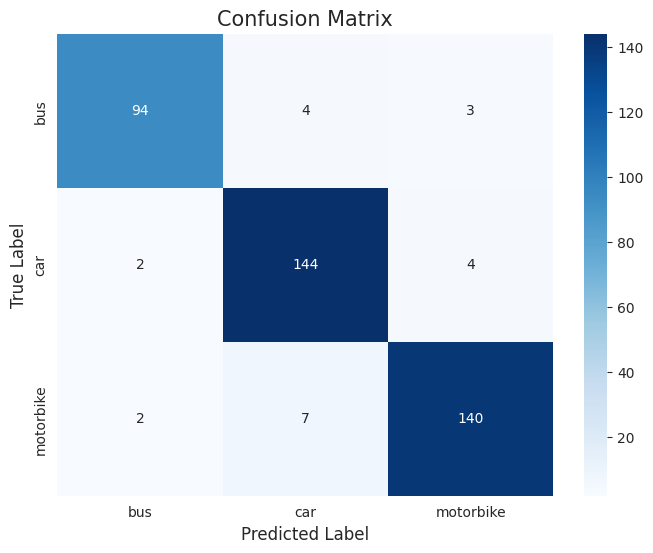

              precision    recall  f1-score   support

         bus       0.96      0.93      0.94       101
         car       0.93      0.96      0.94       150
   motorbike       0.95      0.94      0.95       149

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.95       400



In [12]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

class_names = train_dataset.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)